# *ASSIGNMENT-2: Network robustness*

In [28]:
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import random
from itertools import combinations

### Functions

In [29]:
def largest_component(G):
    """
    Restituisce la componente gigante del grafo G.
    La componente gigante è il gruppo di nodi più grande ancora connesso.
    Dopo ogni attacco, la rete può spezzarsi in più parti: noi analizziamo
    sempre la parte più grande, perché rappresenta la 'rete principale'.
    """
    if G.number_of_nodes() == 0:
        return G  # grafo vuoto → niente da fare

    # Trovo tutte le componenti connesse
    components = nx.connected_components(G)

    # Seleziono quella con più nodi
    largest = max(components, key=len)

    # Restituisco il sottografo corrispondente
    return G.subgraph(largest).copy()

In [30]:
def select_random(G, k):
    """
    Seleziona k nodi a caso dalla componente gigante.
    Simula guasti casuali nella rete.
    """
    nodes = list(G.nodes())
    k = min(k, len(nodes))  # sicurezza
    return random.sample(nodes, k)

In [31]:
def select_degree(G, k):
    """
    Seleziona i k nodi con il grado più alto.
    Colpisce i nodi più connessi → attacco mirato.
    """
    degree_dict = dict(G.degree())
    nodes_sorted = sorted(degree_dict, key=degree_dict.get, reverse=True)
    return nodes_sorted[:k]

In [32]:
def select_pagerank(G, k):
    """
    Seleziona i k nodi con PageRank più alto.
    Tiene conto non solo del grado, ma dell'importanza globale del nodo.
    """
    pr = nx.pagerank(G)
    nodes_sorted = sorted(pr, key=pr.get, reverse=True)
    return nodes_sorted[:k]

In [33]:
def select_betweenness_fast(G, k, sample_size=500):
    """
    Seleziona i k nodi con betweenness più alta.
    Usa una versione approssimata (sample_size) per grafi grandi.
    Se la componente gigante è più piccola di sample_size,
    riduce automaticamente sample_size per evitare errori.
    """

    # Se la componente gigante ha meno nodi del sample_size,
    # riduco sample_size per evitare ValueError
    sample_size = min(sample_size, G.number_of_nodes())

    bt = nx.betweenness_centrality(G, k=sample_size)
    nodes_sorted = sorted(bt, key=bt.get, reverse=True)
    return nodes_sorted[:k]

In [ ]:
def simulate_attack(G, select_nodes, batch_size=1, use_fraction=False):
    """
    Simula un attacco progressivo alla rete.
    Restituisce:
    - x_vals: frazione di nodi rimossi
    - y_vals: dimensione della componente gigante normalizzata
    """

    G_work = G.copy()
    N0 = G_work.number_of_nodes()

    removed = 0
    x_vals = []
    y_vals = []

    # Nome della strategia (solo per eventuali print esterni)
    try:
        attack_name = select_nodes.__name__
    except:
        attack_name = "custom_attack"

    collasso_stampato = False

    while G_work.number_of_nodes() > 0:

        GC = largest_component(G_work)

        # Calcolo quanti nodi rimuovere
        if use_fraction:
            k = max(1, int(batch_size * GC.number_of_nodes()))
        else:
            k = min(batch_size, GC.number_of_nodes())

        # Seleziono i nodi da rimuovere
        nodes_to_remove = select_nodes(GC, k)

        # Rimuovo dal grafo globale
        G_work.remove_nodes_from(nodes_to_remove)
        removed += len(nodes_to_remove)

        # Aggiorno la componente gigante
        GC = largest_component(G_work)

        # Registro i valori
        x_vals.append(removed / N0)
        y_vals.append(GC.number_of_nodes() / N0)

        # COLLASSO (solo un print, opzionale)
        if (not collasso_stampato) and (GC.number_of_nodes() < 0.5 * N0):
            # Se vuoi togliere anche questo print, basta commentarlo
            print(f"COLLASSO: {attack_name} ha ridotto la GC sotto il 50% dopo {removed} nodi rimossi")
            collasso_stampato = True

        if G_work.number_of_nodes() == 0:
            break

    return x_vals, y_vals

In [35]:
def plot_results(results, title="Robustezza della rete"):
    """
    Disegna le curve G/N in funzione della frazione di nodi rimossi.
    Ogni curva rappresenta una strategia di attacco.
    """
    plt.figure(figsize=(8,6))
    for name, (x, y) in results.items():
        plt.plot(x, y, marker='o', label=name)
    plt.xlabel("Frazione nodi rimossi")
    plt.ylabel("G/N (dimensione componente gigante)")
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.show()

In [36]:
batch_ER = 50      # ER → collasso lento → batch piccolo
batch_BA = 25      # BA → collasso rapido → batch medio
batch_ANIME = 200  # Anime → grafo grande → batch più grande

## Use small graphs to write the code

Attacchi grafo Erdos Renyi
⚠️ COLLASSO: select_random ha ridotto la GC sotto il 50% dopo 500 nodi rimossi
⚠️ COLLASSO: select_degree ha ridotto la GC sotto il 50% dopo 500 nodi rimossi
⚠️ COLLASSO: select_pagerank ha ridotto la GC sotto il 50% dopo 500 nodi rimossi
⚠️ COLLASSO: <lambda> ha ridotto la GC sotto il 50% dopo 500 nodi rimossi


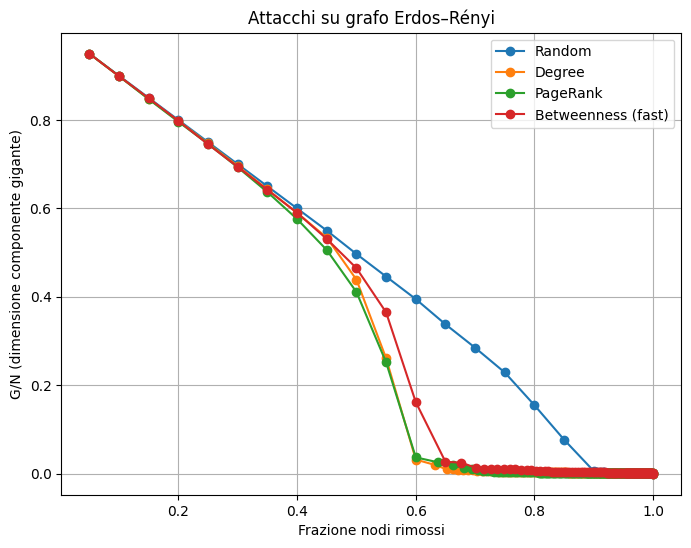

Random 0.0
Degree 0.0
PageRank 0.0
Betweenness (fast) 0.0


In [37]:
G_ER = nx.erdos_renyi_graph(1000, 0.01)
results_ER = {}
print("Attacchi grafo Erdos Renyi")

results_ER["Random"] = simulate_attack(G_ER, select_random, batch_size=batch_ER)
results_ER["Degree"] = simulate_attack(G_ER, select_degree, batch_size=batch_ER)
results_ER["PageRank"] = simulate_attack(G_ER, select_pagerank, batch_size=batch_ER)
results_ER["Betweenness (fast)"] = simulate_attack(
    G_ER,
    lambda G, k: select_betweenness_fast(G, k, sample_size=300),
    batch_size=batch_ER
)

plot_results(results_ER, "Attacchi su grafo Erdos–Rényi")
for name, (_, y) in results_ER.items():
    print(name, min(y))

Attacchi grafo Barabasi Albert
⚠️ COLLASSO: select_random ha ridotto la GC sotto il 50% dopo 500 nodi rimossi
⚠️ COLLASSO: select_degree ha ridotto la GC sotto il 50% dopo 325 nodi rimossi
⚠️ COLLASSO: select_pagerank ha ridotto la GC sotto il 50% dopo 325 nodi rimossi
⚠️ COLLASSO: <lambda> ha ridotto la GC sotto il 50% dopo 350 nodi rimossi


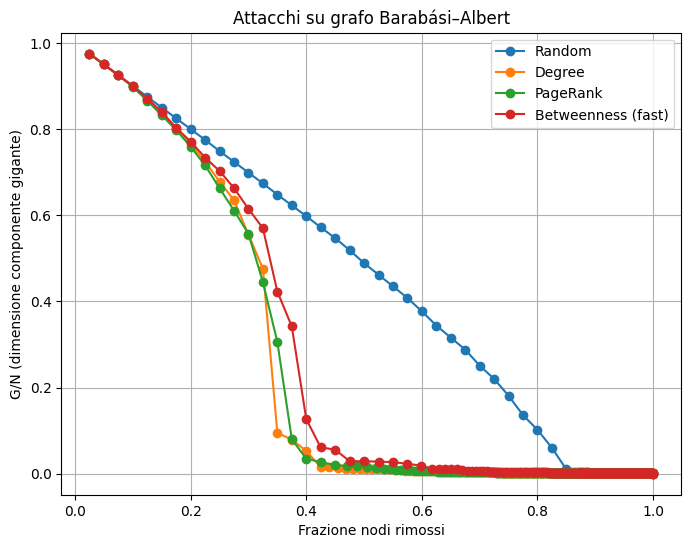

Random 0.0
Degree 0.0
PageRank 0.0
Betweenness (fast) 0.0


In [38]:
G_BA = nx.barabasi_albert_graph(1000, 5)
results_BA = {}
print("Attacchi grafo Barabasi Albert")

results_BA["Random"] = simulate_attack(G_BA, select_random, batch_size=batch_BA)
results_BA["Degree"] = simulate_attack(G_BA, select_degree, batch_size=batch_BA)
results_BA["PageRank"] = simulate_attack(G_BA, select_pagerank, batch_size=batch_BA)
results_BA["Betweenness (fast)"] = simulate_attack(
    G_BA,
    lambda G, k: select_betweenness_fast(G, k, sample_size=300),
    batch_size=batch_BA
)

plot_results(results_BA, "Attacchi su grafo Barabási–Albert")
for name, (_, y) in results_BA.items():
    print(name, min(y))

## Use your graph

In [39]:
BASE_DIR = Path().resolve().parent
DATASET_PATH = BASE_DIR / "data" / "anime_filtered.csv"
filtered = pd.read_csv(DATASET_PATH)

In [40]:
def build_graph(filtered):
    G = nx.Graph()
    for _, row in filtered.iterrows():
        G.add_node(row["mal_id"], title=row["title"])
    for (_, a), (_, b) in combinations(filtered.iterrows(), 2):
        genres_a = set(str(a["genres"]).split("|"))
        genres_b = set(str(b["genres"]).split("|"))
        if len(genres_a & genres_b) >= 2:
            G.add_edge(a["mal_id"], b["mal_id"])
    return G

Attacchi grafo anime
⚠️ COLLASSO: select_random ha ridotto la GC sotto il 50% dopo 1200 nodi rimossi
⚠️ COLLASSO: select_degree ha ridotto la GC sotto il 50% dopo 1200 nodi rimossi
⚠️ COLLASSO: select_pagerank ha ridotto la GC sotto il 50% dopo 1200 nodi rimossi
⚠️ COLLASSO: <lambda> ha ridotto la GC sotto il 50% dopo 1000 nodi rimossi


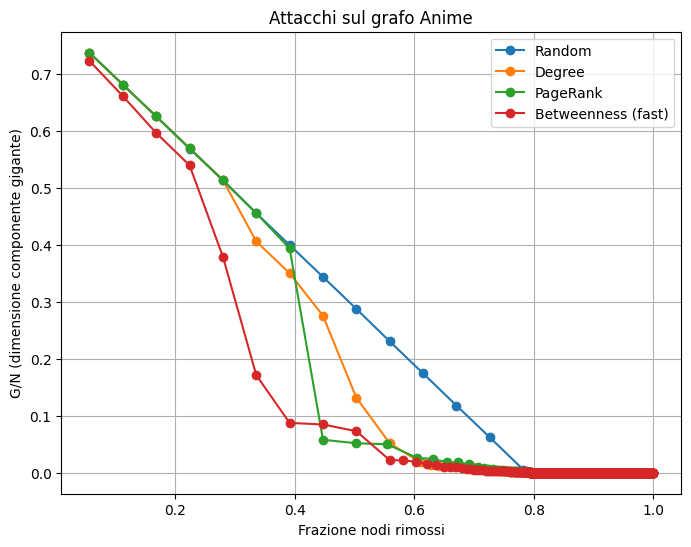

Random 0.0
Degree 0.0
PageRank 0.0
Betweenness (fast) 0.0


In [41]:
G_anime = build_graph(filtered)
results_anime = {}
print("Attacchi grafo anime")
results_anime["Random"] = simulate_attack(G_anime, select_random, batch_size=batch_ANIME)
results_anime["Degree"] = simulate_attack(G_anime, select_degree, batch_size=batch_ANIME)
results_anime["PageRank"] = simulate_attack(G_anime, select_pagerank, batch_size=batch_ANIME)
results_anime["Betweenness (fast)"] = simulate_attack(
    G_anime,
    lambda G, k: select_betweenness_fast(G, k, sample_size=500),
    batch_size=batch_ANIME
)

plot_results(results_anime, "Attacchi sul grafo Anime")
for name, (_, y) in results_anime.items():
    print(name, min(y))

In [42]:
def compute_moments(G):
    """
    Calcola primo e secondo momento della distribuzione del grado.
    """
    degrees = [d for _, d in G.degree()]
    k1 = sum(degrees) / len(degrees)
    k2 = sum(d*d for d in degrees) / len(degrees)
    return k1, k2

In [43]:
def critical_threshold(G):
    """
    Calcola la soglia critica fc per guasti random.
    """
    k1, k2 = compute_moments(G)
    if k2 <= k1:
        return 0  # rete troppo omogenea
    return 1 - 1 / (k2/k1 - 1)

In [44]:
def add_ring_degree(G, top_n=1):
    """
    Aggiunge archi tra i vicini dei top-n nodi per grado.
    """
    G_new = G.copy()
    degree = dict(G.degree())
    top_nodes = sorted(degree, key=degree.get, reverse=True)[:top_n]

    for node in top_nodes:
        neighbors = list(G_new.neighbors(node))
        for i in range(len(neighbors)):
            for j in range(i+1, len(neighbors)):
                if not G_new.has_edge(neighbors[i], neighbors[j]):
                    G_new.add_edge(neighbors[i], neighbors[j])
    return G_new

In [45]:
def add_ring_betweenness(G, top_n=1, sample_size=500):
    """
    Aggiunge archi tra i vicini dei top-n nodi per betweenness stimata.
    """
    G_new = G.copy()
    bt = nx.betweenness_centrality(G, k=sample_size)
    top_nodes = sorted(bt, key=bt.get, reverse=True)[:top_n]

    for node in top_nodes:
        neighbors = list(G_new.neighbors(node))
        for i in range(len(neighbors)):
            for j in range(i+1, len(neighbors)):
                if not G_new.has_edge(neighbors[i], neighbors[j]):
                    G_new.add_edge(neighbors[i], neighbors[j])
    return G_new

In [46]:
def add_edges_high_clustering(G, m=100):
    """
    Aggiunge m archi tra nodi con clustering alto ma non collegati.
    """
    G_new = G.copy()
    clustering = nx.clustering(G_new)
    nodes_sorted = sorted(clustering, key=clustering.get, reverse=True)

    added = 0
    for i in range(len(nodes_sorted)):
        for j in range(i+1, len(nodes_sorted)):
            if added >= m:
                return G_new
            u, v = nodes_sorted[i], nodes_sorted[j]
            if not G_new.has_edge(u, v):
                G_new.add_edge(u, v)
                added += 1
    return G_new

In [47]:
results_robustness = []

In [48]:
# Originale
k1, k2 = compute_moments(G_anime)
fc_original = critical_threshold(G_anime)
results_robustness.append(["Original", G_anime.number_of_nodes(), G_anime.number_of_edges(), k1, k2, fc_original])

In [49]:
# Strategia 1: ring top-3 per grado
G_deg = add_ring_degree(G_anime, top_n=3)
k1d, k2d = compute_moments(G_deg)
fc_deg = critical_threshold(G_deg)
results_robustness.append(["Ring Degree (top-3)", G_deg.number_of_nodes(), G_deg.number_of_edges(), k1d, k2d, fc_deg])

In [50]:
# Strategia 2: ring top-3 per betweenness
G_bt = add_ring_betweenness(G_anime, top_n=3)
k1b, k2b = compute_moments(G_bt)
fc_bt = critical_threshold(G_bt)
results_robustness.append(["Ring Betweenness (top-3)", G_bt.number_of_nodes(), G_bt.number_of_edges(), k1b, k2b, fc_bt])

In [51]:
# Strategia 3: aggiunta archi tra nodi con clustering alto
G_cl = add_edges_high_clustering(G_anime, m=200)
k1c, k2c = compute_moments(G_cl)
fc_cl = critical_threshold(G_cl)
results_robustness.append(["High Clustering (200 edges)", G_cl.number_of_nodes(), G_cl.number_of_edges(), k1c, k2c, fc_cl])

In [52]:
df_results = pd.DataFrame(results_robustness, columns=["Graph", "N", "L", "1st moment", "2nd moment", "fc"])
df_results

,Graph,N,L,1st moment,2nd moment,fc
0,Original,3579,780393,436.095557,3.516982e+05,0.998758
1,Ring Degree (top-3),3579,1720329,961.346186,1.656736e+06,0.999419
2,Ring Betweenness (top-3),3579,2516321,1406.158704,3.074152e+06,0.999542
3,High Clustering (200 edges),3579,780593,436.207320,3.517622e+05,0.998758


In [57]:
print("\n\n=== ATTACCHI DOPO LE STRATEGIE DI ROBUSTEZZA ===")

graphs_robustness = {
    "Original": G_anime,
    "Ring Degree": G_deg,
    "Ring Betweenness": G_bt,
    "High Clustering": G_cl
}

attacks = {
    "Random": select_random,
    "Degree": select_degree,
    "PageRank": select_pagerank,
    # "Betweenness": lambda G, k: select_betweenness_fast(G, k, sample_size=50)
}



=== ATTACCHI DOPO LE STRATEGIE DI ROBUSTEZZA ===


In [58]:
all_results_robustness = {}
for graph_name, graph in graphs_robustness.items():
    all_results_robustness[graph_name] = {}

    for attack_name, attack_function in attacks.items():
        print(f"\n--- {graph_name} | {attack_name} attack ---")
        result = simulate_attack(
            graph,
            attack_function,
            batch_size=batch_ANIME
        )
        all_results_robustness[graph_name][attack_name] = result
        print(f"Minimo G/N: {min(result[1]):.4f}")


--- Original | Random attack ---
⚠️ COLLASSO: select_random ha ridotto la GC sotto il 50% dopo 1200 nodi rimossi
Minimo G/N: 0.0000

--- Original | Degree attack ---
⚠️ COLLASSO: select_degree ha ridotto la GC sotto il 50% dopo 1200 nodi rimossi
Minimo G/N: 0.0000

--- Original | PageRank attack ---
⚠️ COLLASSO: select_pagerank ha ridotto la GC sotto il 50% dopo 1200 nodi rimossi
Minimo G/N: 0.0000

--- Ring Degree | Random attack ---
⚠️ COLLASSO: select_random ha ridotto la GC sotto il 50% dopo 1200 nodi rimossi
Minimo G/N: 0.0000

--- Ring Degree | Degree attack ---
⚠️ COLLASSO: select_degree ha ridotto la GC sotto il 50% dopo 800 nodi rimossi
Minimo G/N: 0.0000

--- Ring Degree | PageRank attack ---
⚠️ COLLASSO: select_pagerank ha ridotto la GC sotto il 50% dopo 1000 nodi rimossi
Minimo G/N: 0.0000

--- Ring Betweenness | Random attack ---
⚠️ COLLASSO: select_random ha ridotto la GC sotto il 50% dopo 1200 nodi rimossi
Minimo G/N: 0.0000

--- Ring Betweenness | Degree attack ---
⚠️ 

## Building robustness

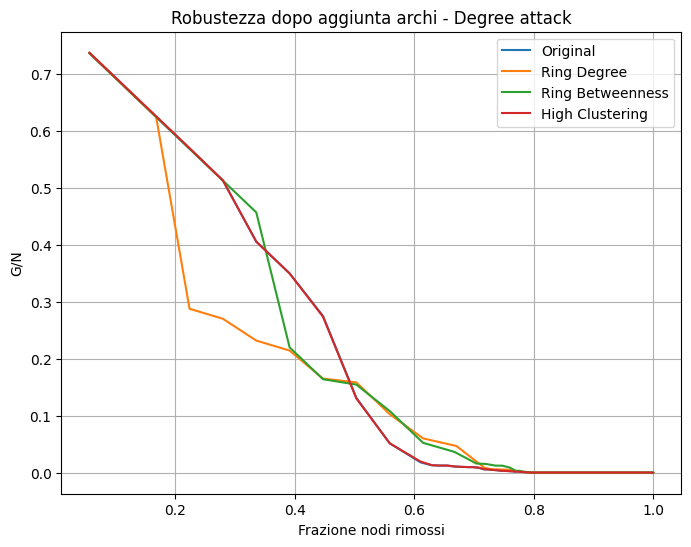

In [59]:
plt.figure(figsize=(8,6))

for graph_name in graphs_robustness:
    x, y = all_results_robustness[graph_name]["Degree"]
    plt.plot(x, y, label=graph_name)

plt.xlabel("Frazione nodi rimossi")
plt.ylabel("G/N")
plt.title("Robustezza dopo aggiunta archi - Degree attack")
plt.legend()
plt.grid(True)
plt.show()